# Lecture 07

### Binning rules of thumb

**"Scott's rule"** assumes gaussian underlying, subject to outliers, suggests that the optimal bin width is

$$\Delta_b = \frac{3.5\sigma}{N^{1/3}}.$$

This makes sense only if the standard deviation $\sigma$ provides a reasonable description of the width of the distribution (e.g., if the distribution is somewhat close to Gaussian). The robust version uses ranked based stats, the **"Freedman-Diaconis rule"** says:

$$\Delta_b = \frac{2(q_{75} - q_{25})}{N^{1/3}} = \frac{2.7\sigma_G}{N^{1/3}}.$$

# The irreducible mass of Black Holes

### Introduciton

For a BH of mass $M$ spin $\chi \in [0, 1]$, the irreducible mass is

$$M_{\rm irr} = M \sqrt{\frac{1 + \sqrt{1 - \chi^2}}{2}}$$

For convenience, let us define

$$f(\chi) = \frac{M_{\rm irr}}{M} = \sqrt{\frac{1 + \sqrt{1 - \chi^2}}{2}}$$

Suppose you have repeated measurements of $M$ and $\chi$. This is just because we're still frequentists for now. When we will put our Bayesian hat on, these distributions will be the *posterior samples* from a single measurement.

Let's assume that

* the spin $\chi$ is uniformly distributed between 0 and 1.
* the mass $M$ is normally distributed with mean $\mu$ and standard deviation $\sigma$.
* (masses and spins are uncorrelated)

These are simplistic assumption that, however, are not too far from what we are now measuring with gravitational-wave detectors. It's a toy model, but not a totally unreasonable one.

**Tasks:**

1. Start with a value of $\sigma = 0.02$. Note that $\mu$ is a scale and not a parameter: you can normalize all quantities with a dimension of mass by $\mu$. Just set $\mu = 1$ in your code and remember that all masses in the problem are measured in units of $\mu$.
2. Plot the resulting pdf of $M_{\rm irr}$. First try an histogram with one the rules of thumb we've seen above.

*Hint (for point 2)*: You don't know the functional form of the pdf of $M_{\rm irr}$... but you don't need it if you just want to generate samples! That's the nice thing about numerics!

3. Using the same samples, plot the distribution of $M_{\rm irr}$ using a KDE.
4. Compute the KS distance between $M_{\rm irr}/\mu$ and $f$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.
5. Compute the KS distance between $M_{\rm irr}$ and $M$ as a function of $\sigma$. Discuss the limits at large and small values of $\sigma$.

*Hint (for points 4 and 5)*. This is a KS test between two sets for samples, `scipy.stats.ks_2samp`.

You should find that (i) $M_{\rm irr}$ is distributed like $f$ if $\sigma \ll \mu$ and (ii) $M_{\rm irr}$ is distributed like $M$ if $\sigma \gg \mu$.

7. Compute the pdf of $f$ from its mathematical definition (pen and paper!). Verify this result:

$$\pi(f) = 2 \frac{2f^2 - 1}{\sqrt{1 - f^2}}.$$

8. Compute the pdfs of $M_{\rm irr}$ from its mathematical definition (pen and paper!). Verify this result:

$$p(M_{\rm irr}) = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp\left[ -\frac{(M_{\rm irr}/f - \mu)^2}{2\sigma^2} \right] \frac{2f^2 - 1}{f\sqrt{1 - f^2}} \, \mathrm{d}f$$

The this expression is only semi-analytic; that integral should then be solved numerically.

*Point 7 and point 8 are **not examinable**; those are interesting calculations but you can just assume those expressions and move on with point 9 if you want.*

*Hint (for point 8)*: You want to use this theorem for the product of two random variables.

9. Using the expressions from point 7 and 8, plot those pdfs check that they agree with your KDE reconstructions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde, ks_2samp

np.random.seed(42) 
N_samples = 10000
mu = 1.0           
sigma = 0.02

def calcola_f(chi):
    return np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)

In [2]:
chi_samples = np.random.uniform(0, 1, N_samples)
M_samples = np.random.normal(mu, sigma, N_samples)

f_samples = calcola_f(chi_samples)
#print(f_samples)
#compongo masse e spin e calcolo Mirr
Mirr_samples = M_samples * f_samples

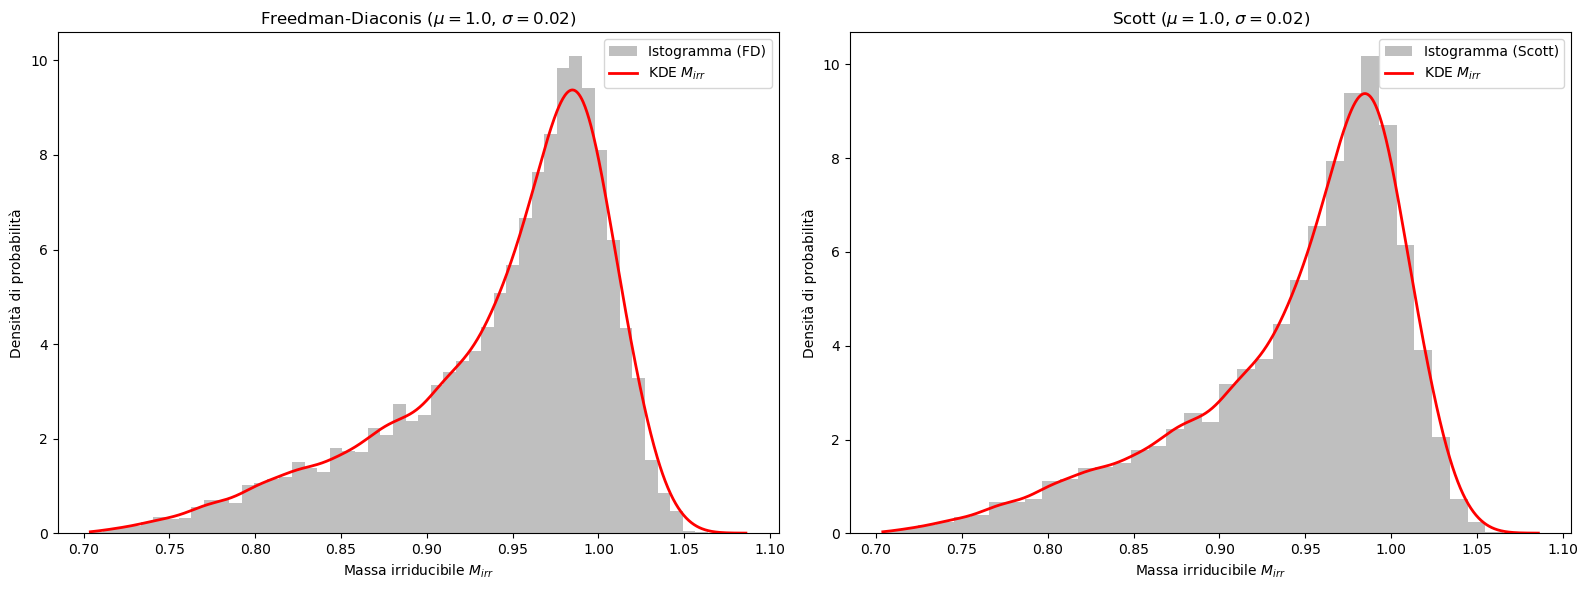

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
kde = gaussian_kde(Mirr_samples)
x_grid = np.linspace(Mirr_samples.min(), Mirr_samples.max(), 1000)


ax1.hist(Mirr_samples, bins='fd', density=True, alpha=0.5, color='gray', 
         label='Istogramma (FD)')
ax1.plot(x_grid, kde(x_grid), color='red', lw=2, label='KDE $M_{irr}$')

ax1.set_title(rf"Freedman-Diaconis ($\mu={mu}$, $\sigma={sigma}$)")
ax1.set_xlabel(r"Massa irriducibile $M_{irr}$")
ax1.set_ylabel("Densità di probabilità")
ax1.legend()


ax2.hist(Mirr_samples, bins='scott', density=True, alpha=0.5, color='gray', 
         label='Istogramma (Scott)')
ax2.plot(x_grid, kde(x_grid), color='red', lw=2, label='KDE $M_{irr}$')

ax2.set_title(rf"Scott ($\mu={mu}$, $\sigma={sigma}$)")
ax2.set_xlabel(r"Massa irriducibile $M_{irr}$")
ax2.set_ylabel("Densità di probabilità")
ax2.legend()

plt.tight_layout()
plt.show()


Kolmogorov Smirnov show esiste una distanza che dipende solo dalle CDF di ogni pdf
La distanza KS è legata a confindence e pvalue.

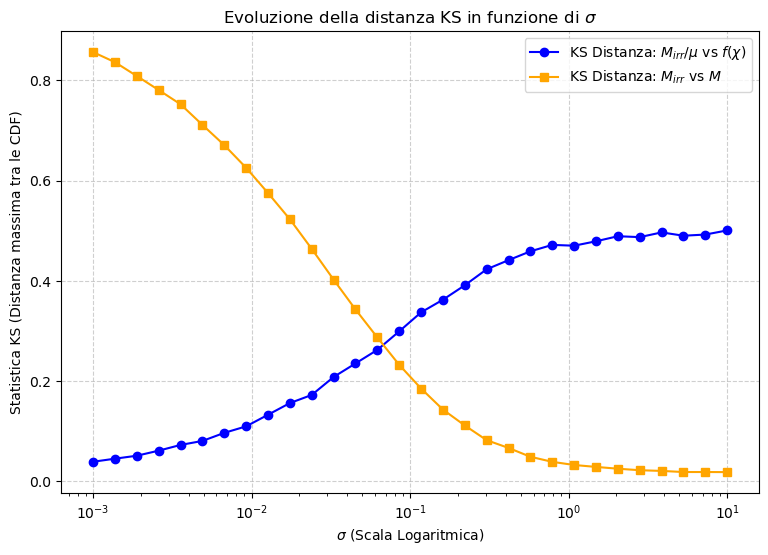

In [ ]:
sigmas = np.logspace(-3, 1, 30)

ks_dist_f = []
ks_dist_M = []
p_value_f = []
p_value_M = []

for s in sigmas:
    M_samples = np.random.normal(mu,s,10000)
    Mirr_samples = (f_samples*M_samples)/mu
    
    stat_f, pval_f = ks_2samp(Mirr_samples, f_samples)
    ks_dist_f.append(stat_f)
    
    stat_M, pval_M = ks_2samp(Mirr_samples, M_samples)
    ks_dist_M.append(stat_M)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(sigmas, ks_dist_f, 'o-', color='blue', label=r'KS Distanza: $M_{irr}/ \mu$ vs $f(\chi)$')
ax.plot(sigmas, ks_dist_M, 's-', color='orange', label=r'KS Distanza: $M_{irr}$ vs $M$')

ax.set_xscale('log')
ax.set_title(r"Evoluzione della distanza KS in funzione di $\sigma$")
ax.set_xlabel(r"$\sigma$ (Scala Logaritmica)")
ax.set_ylabel(r"Statistica KS (Distanza massima tra le CDF)")
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.show()

### Physical Interpretation



Our KS-test analysis reveals how measurement uncertainty dictates our ability to extract physical parameters:

* **High Noise Regime ($\sigma \gg \mu$):** As the variance on the mass measurement grows, the noise completely dominates the narrow geometric bounds of the spin function $f(\chi)$. The PDF of the irreducible mass ($M_{\rm irr}$) degenerates into the PDF of the mass ($M$). In this regime, the spin information is entirely washed out by the detector's uncertainty.
* **High Accuracy Regime ($\sigma \ll \mu$):** If our detector is highly accurate, the mass $M$ is effectively constrained. The observed variations in $M_{\rm irr}$ are strictly driven by the spin distribution $f(\chi)$. Measuring $M_{\rm irr}$ allows us to directly capture the spin of the black hole. 

**Conclusion:** To extract spin information from a composite parameter like $M_{\rm irr}$, the measurement error on the mass must be strictly smaller than the intrinsic variation caused by the spin itself.

### Task 9

Check if analytical pdfs agree with estimation with KDE

$$
\pi(f) = 2 \frac{2f^2 - 1}{\sqrt{1 - f^2}} .
$$



$$
p(M_{\text{irr}}) = \frac{\sqrt{2/\pi}}{\sigma} \int_{1/\sqrt{2}}^1 \exp \left[ - \frac{(M_{\text{irr}}/f - \mu)^2}{2\sigma^2} \right] \frac{2f^2 - 1}{f\sqrt{1 - f^2}} \, \mathrm{d}f
$$

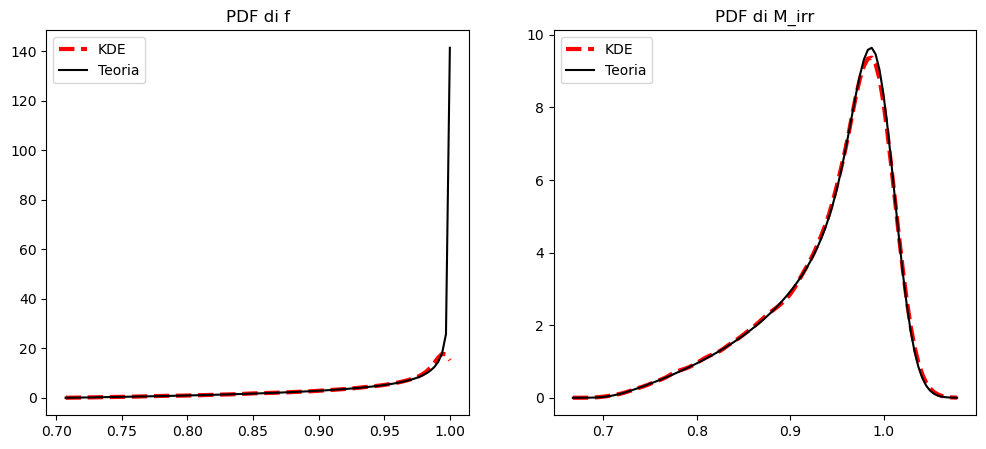

In [6]:
from scipy.stats import gaussian_kde as kde
from scipy.integrate import quad

chi = np.random.uniform(0, 1, 100000)
f = np.sqrt((1 + np.sqrt(1 - chi**2)) / 2)
M_irr = np.random.normal(1.0, 0.02, 100000) * f

#funzione pi(f)
c = lambda x: np.clip(x, 0, 0.9999)
pdf_f = lambda x: 2 * (2 * c(x)**2 - 1) / np.sqrt(1 - c(x)**2)
#funzione p(M)
int_m = lambda f_, m: np.exp(-((m/f_ - 1.0)**2)/0.0008) * (2*f_**2 - 1) / (f_ * np.sqrt(1 - f_**2))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
x_f, x_m = np.linspace(1/np.sqrt(2), 1, 100), np.linspace(M_irr.min(), M_irr.max(), 100)

ax1.plot(x_f, kde(f,'scott')(x_f), 'r--', lw=3, label='KDE')
ax1.plot(x_f, pdf_f(x_f), 'k', label='Teoria')
ax1.set_title("PDF di f"); ax1.legend()

ax2.plot(x_m, kde(M_irr)(x_m), 'r--', lw=3, label='KDE')
# L'integrale numerico viene risolto al volo dentro la chiamata del plot
ax2.plot(x_m, [(np.sqrt(2/np.pi)/0.02) * quad(int_m, 1/np.sqrt(2), 1, args=(m,))[0] for m in x_m], 'k', label='Teoria')
ax2.set_title("PDF di M_irr"); ax2.legend()

plt.show()